# **Task 4: Unveiling the Android App Market**

Google Play Store Apps & User Reviews Analysis

OASIS Infobyte: Data Analytics Internship


In [1]:
# OASIS Infobyte - Task 4
# Google Play Store Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Environment setup completed successfully.")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Environment setup completed successfully.
Pandas version: 2.2.3
NumPy version: 2.1.3


In [2]:
from google.colab import files
uploaded=files.upload()

Saving googleplaystore.csv to googleplaystore.csv
Saving googleplaystore_user_reviews.csv to googleplaystore_user_reviews.csv


# **Loading the Play Store apps dataset**

In [3]:
# Loading the Datasets
apps=pd.read_csv('googleplaystore.csv')
reviews=pd.read_csv('googleplaystore_user_reviews.csv')

### **Inspecting The Dataset**

In [4]:
print("Apps dataset shape:", apps.shape)
print("Reviews dataset shape:", reviews.shape)

Apps dataset shape: (10841, 13)
Reviews dataset shape: (64295, 5)


In [5]:
print("APP DATASET COLUMNS:")
print(apps.columns.tolist())

print("\nREVIEW DATASET COLUMNS:")
print(reviews.columns.tolist())

APP DATASET COLUMNS:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

REVIEW DATASET COLUMNS:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [6]:
print("APP DATASET INFO")
apps.info()

print("\n" + "="*60 + "\n")

print("REVIEWS DATASET INFO")
reviews.info()


APP DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


REVIEWS DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column    

In [7]:
# Missing Value
print("Missing values in Apps dataset:")
print(apps.isnull().sum())

print("\n" + "="*60 + "\n")

print("Missing values in Reviews dataset:")
print(reviews.isnull().sum())

Missing values in Apps dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


Missing values in Reviews dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [8]:
#Checking Duplicates
print("Duplicate rows in Apps dataset:", apps.duplicated().sum())
print("Duplicate rows in Reviews dataset:", reviews.duplicated().sum())

Duplicate rows in Apps dataset: 483
Duplicate rows in Reviews dataset: 33616


In [9]:
# Inspeccting Duplicates

print("Sample duplicate rows from Apps:")
display(apps[apps.duplicated(keep=False)].head(10))

print("\n" + "="*60 + "\n")

print("Sample duplicate rows from Reviews:")
display(reviews[reviews.duplicated(keep=False)].head(10))

Sample duplicate rows from Apps:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
164,Ebook Reader,BOOKS_AND_REFERENCE,4.1,85842,37M,"5,000,000+",Free,0,Everyone,Books & Reference,"June 25, 2018",5.0.6,4.0 and up
192,Docs To Go™ Free Office Suite,BUSINESS,4.1,217730,Varies with device,"50,000,000+",Free,0,Everyone,Business,"April 2, 2018",Varies with device,Varies with device
193,Google My Business,BUSINESS,4.4,70991,Varies with device,"5,000,000+",Free,0,Everyone,Business,"July 24, 2018",2.19.0.204537701,4.4 and up
204,Box,BUSINESS,4.2,159872,Varies with device,"10,000,000+",Free,0,Everyone,Business,"July 31, 2018",Varies with device,Varies with device
213,ZOOM Cloud Meetings,BUSINESS,4.4,31614,37M,"10,000,000+",Free,0,Everyone,Business,"July 20, 2018",4.1.28165.0716,4.0 and up
222,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
228,SignEasy | Sign and Fill PDF and other Documents,BUSINESS,4.3,8978,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 25, 2018",Varies with device,Varies with device
229,Quick PDF Scanner + OCR FREE,BUSINESS,4.2,80805,Varies with device,"5,000,000+",Free,0,Everyone,Business,"February 26, 2018",Varies with device,4.0.3 and up
230,Genius Scan - PDF Scanner,BUSINESS,4.4,42492,Varies with device,"1,000,000+",Free,0,Everyone,Business,"July 11, 2018",Varies with device,Varies with device
231,Tiny Scanner - PDF Scanner App,BUSINESS,4.7,286897,39M,"10,000,000+",Free,0,Everyone,Business,"May 30, 2017",1.2.6,3.0 and up




Sample duplicate rows from Reviews:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
5,10 Best Foods for You,Best way,Positive,1.00,0.300000
6,10 Best Foods for You,Amazing,Positive,0.60,0.900000
7,10 Best Foods for You,NaN,NaN,NaN,NaN
8,10 Best Foods for You,"Looking forward app,",Neutral,0.00,0.000000
9,10 Best Foods for You,It helpful site ! It help foods get !,Neutral,0.00,0.000000


In [10]:
# Quantifying The Duplicate Situation

print("Apps:")
print("Total rows:", len(apps))
print("Exact duplicate rows:", apps.duplicated().sum())
print("Rows after removing exact duplicates:", len(apps.drop_duplicates()))

print("\nReviews:")
print("Total rows:", len(reviews))
print("Exact duplicate rows:", reviews.duplicated().sum())
print("Rows after removing exact duplicates:", len(reviews.drop_duplicates()))

print("\nCompletely empty review-text rows:", reviews["Translated_Review"].isna().sum())

Apps:
Total rows: 10841
Exact duplicate rows: 483
Rows after removing exact duplicates: 10358

Reviews:
Total rows: 64295
Exact duplicate rows: 33616
Rows after removing exact duplicates: 30679

Completely empty review-text rows: 26868


In [11]:
# actual values in the messy numerical columns

print("SIZE VALUES:")
print(apps["Size"].value_counts().head(15))

print("\n" + "="*60)

print("INSTALL VALUES:")
print(apps["Installs"].value_counts().head(15))

print("\n" + "="*60)

print("PRICE VALUES:")
print(apps["Price"].value_counts().head(15))

print("\n" + "="*60)

print("REVIEWS VALUES:")
print(apps["Reviews"].head(15))

SIZE VALUES:
Size
Varies with device    1695
11M                    198
12M                    196
14M                    194
13M                    191
15M                    184
17M                    160
19M                    154
16M                    149
26M                    149
25M                    143
20M                    139
21M                    138
24M                    136
10M                    136
Name: count, dtype: int64

INSTALL VALUES:
Installs
1,000,000+      1579
10,000,000+     1252
100,000+        1169
10,000+         1054
1,000+           907
5,000,000+       752
100+             719
500,000+         539
50,000+          479
5,000+           477
100,000,000+     409
10+              386
500+             330
50,000,000+      289
50+              205
Name: count, dtype: int64

PRICE VALUES:
Price
0          10040
$0.99        148
$2.99        129
$1.99         73
$4.99         72
$3.99         63
$1.49         46
$5.99         30
$2.49         26
$9.99     

## **Data Quality Assessment**

Initial inspection identified the following issues that need to be addressed before analysis:

- **483 exact duplicate rows** in the Apps dataset.
- **33,616 exact duplicate rows** in the Reviews dataset.
- **1,474 missing ratings** in the Apps dataset.
- **26,868 missing review texts** in the Reviews dataset.
- `Reviews` is stored as text instead of numeric.
- `Installs` contains commas and `+` symbols (e.g., `10,000+`).
- `Price` contains `$` symbols (e.g., `$4.99`).
- `Size` contains units such as `M` and `k`, as well as `Varies with device`.

These issues will be addressed during the cleaning stage while preserving valid records and avoiding unnecessary changes to the original data.

# **Data Cleaning Phase**

In [12]:
apps_clean = apps.drop_duplicates().copy()

print("Original rows:", len(apps))
print("Rows after removing duplicates:", len(apps_clean))
print("Rows removed:", len(apps) - len(apps_clean))

Original rows: 10841
Rows after removing duplicates: 10358
Rows removed: 483


In [13]:
# Converting "Reviews" to numeric
apps_clean["Reviews"] = pd.to_numeric(apps_clean["Reviews"], errors="coerce")

print(apps_clean["Reviews"].dtype)
print("Missing Reviews after conversion:", apps_clean["Reviews"].isna().sum())

float64
Missing Reviews after conversion: 1


In [14]:
# Cleaning "Installs (the column)"

apps_clean["Installs"] = (
    apps_clean["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

apps_clean["Installs"] = pd.to_numeric(
    apps_clean["Installs"],
    errors="coerce"
)

print("Installs data type:", apps_clean["Installs"].dtype)
print("Missing Installs after conversion:", apps_clean["Installs"].isna().sum())

print("\nSample cleaned Install values:")
print(apps_clean["Installs"].head(10))

Installs data type: float64
Missing Installs after conversion: 1

Sample cleaned Install values:
0       10000.0
1      500000.0
2     5000000.0
3    50000000.0
4      100000.0
5       50000.0
6       50000.0
7     1000000.0
8     1000000.0
9       10000.0
Name: Installs, dtype: float64


In [15]:
# Verifying the Converssion

print("Install statistics:")
print(apps_clean["Installs"].describe())

Install statistics:
count    1.035700e+04
mean     1.415776e+07
std      8.023955e+07
min      0.000000e+00
25%      1.000000e+03
50%      1.000000e+05
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64


In [16]:
print("\nUnique install values:")
print(sorted(apps_clean["Installs"].dropna().unique())[:30])


Unique install values:
[np.float64(0.0), np.float64(1.0), np.float64(5.0), np.float64(10.0), np.float64(50.0), np.float64(100.0), np.float64(500.0), np.float64(1000.0), np.float64(5000.0), np.float64(10000.0), np.float64(50000.0), np.float64(100000.0), np.float64(500000.0), np.float64(1000000.0), np.float64(5000000.0), np.float64(10000000.0), np.float64(50000000.0), np.float64(100000000.0), np.float64(500000000.0), np.float64(1000000000.0)]


In [17]:
# Cleaning "Price (the column)" , meaning removing the $ signia

apps_clean["Price"] = (
    apps_clean["Price"]
    .str.replace("$", "", regex=False)
)

apps_clean["Price"] = pd.to_numeric(
    apps_clean["Price"],
    errors="coerce"
)

print("Price data type:", apps_clean["Price"].dtype)
print("Missing Price after conversion:", apps_clean["Price"].isna().sum())

print("\nSample cleaned Price values:")
print(apps_clean["Price"].head(10))

Price data type: float64
Missing Price after conversion: 1

Sample cleaned Price values:
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
Name: Price, dtype: float64


In [18]:
print("Price statistics:")
print(apps_clean["Price"].describe())

Price statistics:
count    10357.000000
mean         1.030800
std         16.278625
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        400.000000
Name: Price, dtype: float64


In [19]:
print("\nUnique Price values:")
print(sorted(apps_clean["Price"].dropna().unique())[:30])


Unique Price values:
[np.float64(0.0), np.float64(0.99), np.float64(1.0), np.float64(1.04), np.float64(1.2), np.float64(1.26), np.float64(1.29), np.float64(1.49), np.float64(1.5), np.float64(1.59), np.float64(1.61), np.float64(1.7), np.float64(1.75), np.float64(1.76), np.float64(1.96), np.float64(1.97), np.float64(1.99), np.float64(2.0), np.float64(2.49), np.float64(2.5), np.float64(2.56), np.float64(2.59), np.float64(2.6), np.float64(2.9), np.float64(2.95), np.float64(2.99), np.float64(3.02), np.float64(3.04), np.float64(3.08), np.float64(3.28)]


In [20]:
# Inspecting "Size" values before conversion

print("Number of unique Size values:", apps_clean["Size"].nunique())

print("\nSample Size values:")
print(apps_clean["Size"].value_counts().head(30))

Number of unique Size values: 462

Sample Size values:
Size
Varies with device    1526
11M                    188
13M                    186
12M                    186
14M                    182
15M                    174
17M                    155
26M                    145
16M                    143
19M                    135
10M                    133
20M                    131
25M                    131
21M                    130
24M                    129
18M                    124
23M                    109
22M                    108
29M                     95
27M                     94
28M                     92
30M                     84
33M                     78
3.3M                    76
37M                     72
31M                     69
35M                     68
2.5M                    68
2.3M                    68
2.9M                    67
Name: count, dtype: int64


In [21]:
# Cleaning "Size" and converting all values to MB

def convert_size_to_mb(size):
    if pd.isna(size):
        return np.nan

    if size == "Varies with device":
        return np.nan

    if size.endswith("M"):
        return float(size.replace("M", ""))

    if size.endswith("k"):
        return float(size.replace("k", "")) / 1024

    return np.nan


apps_clean["Size"] = apps_clean["Size"].apply(convert_size_to_mb)

print("Size data type:", apps_clean["Size"].dtype)
print("Missing Size after conversion:", apps_clean["Size"].isna().sum())

print("\nSample cleaned Size values:")
print(apps_clean["Size"].head(15))

Size data type: float64
Missing Size after conversion: 1527

Sample cleaned Size values:
0     19.0
1     14.0
2      8.7
3     25.0
4      2.8
5      5.6
6     19.0
7     29.0
8     33.0
9      3.1
10    28.0
11    12.0
12    20.0
13    21.0
14    37.0
Name: Size, dtype: float64


In [22]:
#Validating the change
print("Size statistics:")
print(apps_clean["Size"].describe())

Size statistics:
count    8831.000000
mean       21.287413
std        22.540591
min         0.008301
25%         4.700000
50%        13.000000
75%        29.000000
max       100.000000
Name: Size, dtype: float64


In [23]:
print("\nNumber of missing Size values:", apps_clean["Size"].isna().sum())

print("\nLargest app sizes:")
print(apps_clean[["App", "Size"]].sort_values("Size", ascending=False).head(10))


Number of missing Size values: 1527

Largest app sizes:
                                    App   Size
2299               Navi Radiography Pro  100.0
1988             Hungry Shark Evolution  100.0
3973             Hungry Shark Evolution  100.0
1080                          Post Bank  100.0
7404                    SimCity BuildIt  100.0
1565     Talking Babsy Baby: Baby Games  100.0
1758             Hungry Shark Evolution  100.0
1793  Mini Golf King - Multiplayer Game  100.0
9170      Stickman Legends: Shadow Wars  100.0
4690                         Vi Trainer  100.0


In [24]:
# Checking remaining missing values after numerical cleaning

print("Remaining missing values in Apps dataset:")
print(apps_clean.isnull().sum())

Remaining missing values in Apps dataset:
App                  0
Category             0
Rating            1465
Reviews              1
Size              1527
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


In [25]:
print("\nRemaining missing values in Reviews dataset:")
print(reviews.isnull().sum())


Remaining missing values in Reviews dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


### **Handling Missing Values**

After removing duplicate records and converting numerical columns, some missing values remained in the Apps dataset.

Missing values were retained rather than filled with arbitrary estimates because the missing information cannot be reliably inferred from the available data. In particular, missing ratings, prices, sizes, and install counts were not replaced with averages or zeros to avoid introducing artificial values.

The `Size` values recorded as `Varies with device` were also represented as missing because they do not correspond to a single fixed app size.

For the Reviews dataset, missing review text will be excluded only from sentiment analysis because sentiment classification requires actual review text. The original review dataset is otherwise preserved.

In [26]:
# Removing exact duplicate rows from Reviews dataset

reviews_clean = reviews.drop_duplicates().copy()

print("Original rows:", len(reviews))
print("Rows after removing duplicates:", len(reviews_clean))
print("Rows removed:", len(reviews) - len(reviews_clean))

Original rows: 64295
Rows after removing duplicates: 30679
Rows removed: 33616


In [27]:
#Quick Vlaidation
print("Remaining exact duplicates:", reviews_clean.duplicated().sum())

Remaining exact duplicates: 0


In [28]:
# Inspect rows with missing review text but existing sentiment information

missing_text_with_sentiment = reviews_clean[
    reviews_clean["Translated_Review"].isna() &
    reviews_clean["Sentiment"].notna()
]

print("Rows with missing review text but existing sentiment:",
      len(missing_text_with_sentiment))

display(missing_text_with_sentiment)

Rows with missing review text but existing sentiment: 5


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
268,11st,NaN,Neutral,0.0,0.0
15048,Birds Sounds Ringtones & Wallpapers,NaN,Neutral,0.0,0.0
22092,Calorie Counter - MyFitnessPal,NaN,Neutral,0.0,0.0
31623,DC Comics,NaN,Neutral,0.0,0.0
52500,Garden Photo Frames - Garden Photo Editor,NaN,Neutral,0.0,0.0


In [29]:
# Final Apps dataset validation

print("FINAL APPS DATASET")


print("Shape:", apps_clean.shape)

print("\nData types:")
print(apps_clean.dtypes)

print("\nMissing values:")
print(apps_clean.isnull().sum())

print("\nExact duplicates:", apps_clean.duplicated().sum())

FINAL APPS DATASET
Shape: (10358, 13)

Data types:
App                object
Category           object
Rating            float64
Reviews           float64
Size              float64
Installs          float64
Type               object
Price             float64
Content Rating     object
Genres             object
Last Updated       object
Current Ver        object
Android Ver        object
dtype: object

Missing values:
App                  0
Category             0
Rating            1465
Reviews              1
Size              1527
Installs             1
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

Exact duplicates: 0


In [30]:
# Final Reviews dataset validation

print("FINAL REVIEWS DATASET")


print("Shape:", reviews_clean.shape)

print("\nData types:")
print(reviews_clean.dtypes)

print("\nMissing values:")
print(reviews_clean.isnull().sum())

print("\nExact duplicates:", reviews_clean.duplicated().sum())

FINAL REVIEWS DATASET
Shape: (30679, 5)

Data types:
App                        object
Translated_Review          object
Sentiment                  object
Sentiment_Polarity        float64
Sentiment_Subjectivity    float64
dtype: object

Missing values:
App                         0
Translated_Review         987
Sentiment                 982
Sentiment_Polarity        982
Sentiment_Subjectivity    982
dtype: int64

Exact duplicates: 0


In [31]:
# Creating final datasets for analysis

apps_analysis = apps_clean.copy()
reviews_analysis = reviews_clean.copy()

print("Analysis datasets created successfully.")
print("Apps:", apps_analysis.shape)
print("Reviews:", reviews_analysis.shape)

Analysis datasets created successfully.
Apps: (10358, 13)
Reviews: (30679, 5)


# **Category Analysis**

In [32]:
# Category Distribution

category_counts = apps_analysis["Category"].value_counts()

print("Number of categories:", category_counts.nunique())
print("\nApps per category:")
print(category_counts)

Number of categories: 32

Apps per category:
Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
PARENTING                60
COMICS                   60
BEAUTY                   53
1.9                   

In [33]:
# Inspecting the malformed category record

display(
    apps_analysis[apps_analysis["Category"] == "1.9"].T
)

,10472
App,Life Made WI-Fi Touchscreen Photo Frame
Category,1.9
Rating,19.0
Reviews,NaN
Size,NaN
Installs,NaN
Type,0
Price,NaN
Content Rating,NaN
Genres,"February 11, 2018"


In [34]:
# Removing the identified corrupted record

apps_analysis = apps_analysis[apps_analysis["Category"] != "1.9"].copy()

print("Rows after removing corrupted record:", len(apps_analysis))
print("Remaining invalid category entries:",
      (apps_analysis["Category"] == "1.9").sum())

Rows after removing corrupted record: 10357
Remaining invalid category entries: 0


In [35]:
# Recalculate category distribution after cleaning

category_counts = apps_analysis["Category"].value_counts()

print("Number of valid categories:", len(category_counts))
print("\nApps per category:")
print(category_counts)

Number of valid categories: 33

Apps per category:
Category
FAMILY                 1943
GAME                   1121
TOOLS                   843
BUSINESS                427
MEDICAL                 408
PRODUCTIVITY            407
PERSONALIZATION         388
LIFESTYLE               373
COMMUNICATION           366
FINANCE                 360
SPORTS                  351
PHOTOGRAPHY             322
HEALTH_AND_FITNESS      306
SOCIAL                  280
NEWS_AND_MAGAZINES      264
TRAVEL_AND_LOCAL        237
BOOKS_AND_REFERENCE     230
SHOPPING                224
DATING                  196
VIDEO_PLAYERS           175
MAPS_AND_NAVIGATION     137
EDUCATION               130
FOOD_AND_DRINK          124
ENTERTAINMENT           111
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
HOUSE_AND_HOME           80
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dty

### Category Analysis

The cleaned Apps dataset was examined to understand how apps are distributed across Google Play Store categories.

The initial category check identified one malformed record where `Category` was recorded as `1.9`. Inspection of the row showed that multiple values were shifted into incorrect columns, making the record unreliable for analysis. Since the original values could not be reconstructed with confidence, this single corrupted record was excluded from the analysis dataset.

After this correction, the dataset contained **10,357 app records across 33 valid categories**.

The category distribution was then calculated to identify the categories with the largest number of apps. Categories with more apps are treated as having greater **representation and potential competition** within the dataset, rather than being described as commercially saturated without additional market-demand data.

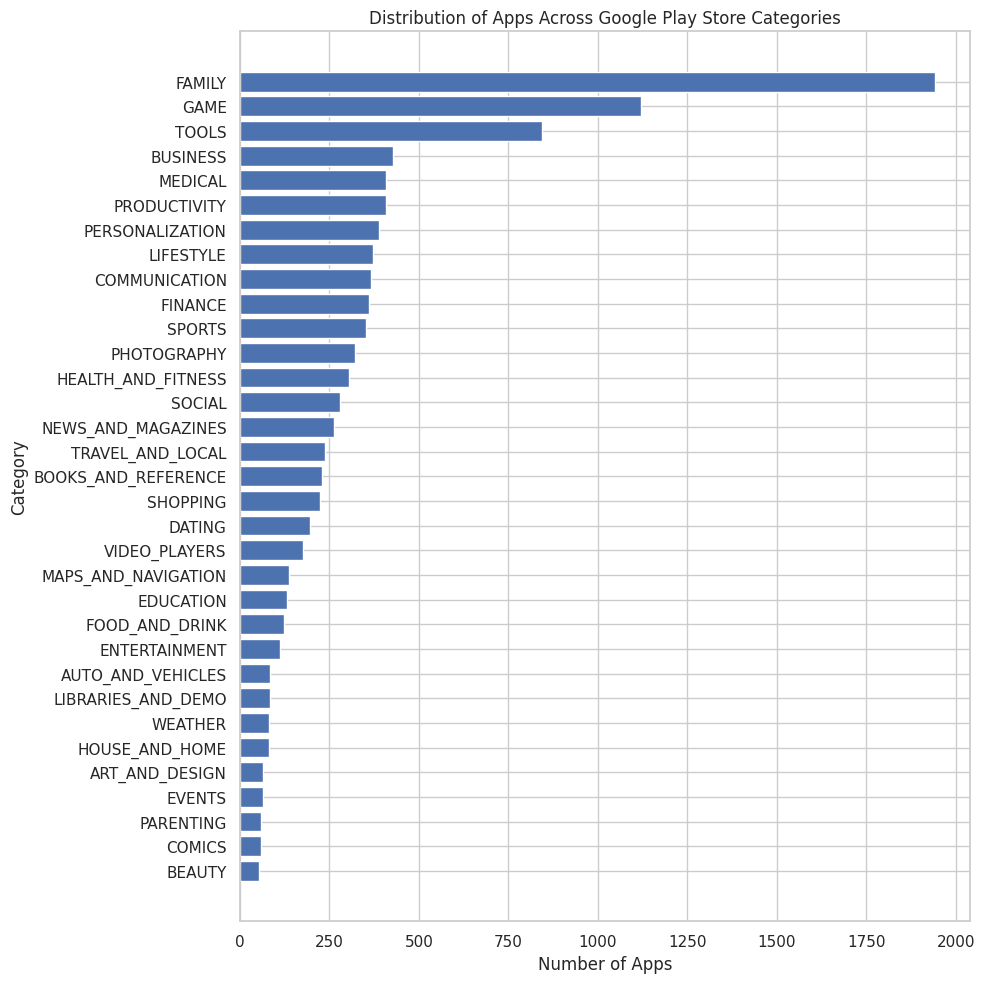

In [36]:
# App Distribution Across Categories

category_counts = apps_analysis["Category"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 10))

plt.barh(category_counts.index, category_counts.values)

plt.title("Distribution of Apps Across Google Play Store Categories")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [37]:
print("Top 10 categories by number of apps:")
print(category_counts.sort_values(ascending=False).head(10))

Top 10 categories by number of apps:
Category
FAMILY             1943
GAME               1121
TOOLS               843
BUSINESS            427
MEDICAL             408
PRODUCTIVITY        407
PERSONALIZATION     388
LIFESTYLE           373
COMMUNICATION       366
FINANCE             360
Name: count, dtype: int64


# **Rating Analysis**

In [38]:
# Rating Analysis - Initial Inspection

print("Rating statistics:")
print(apps_analysis["Rating"].describe())

Rating statistics:
count    8892.000000
mean        4.187877
std         0.522377
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64


In [39]:
# Checking for ratings outside the expected 1-5 range

invalid_ratings = apps_analysis[
    (apps_analysis["Rating"] < 1) |
    (apps_analysis["Rating"] > 5)
]

print("Number of invalid ratings:", len(invalid_ratings))

if len(invalid_ratings) > 0:
    display(invalid_ratings[["App", "Rating"]])

Number of invalid ratings: 0


In [40]:
# Available vs missing ratings

print("Total app records:", len(apps_analysis))
print("Available ratings:", apps_analysis["Rating"].notna().sum())
print("Missing ratings:", apps_analysis["Rating"].isna().sum())

Total app records: 10357
Available ratings: 8892
Missing ratings: 1465


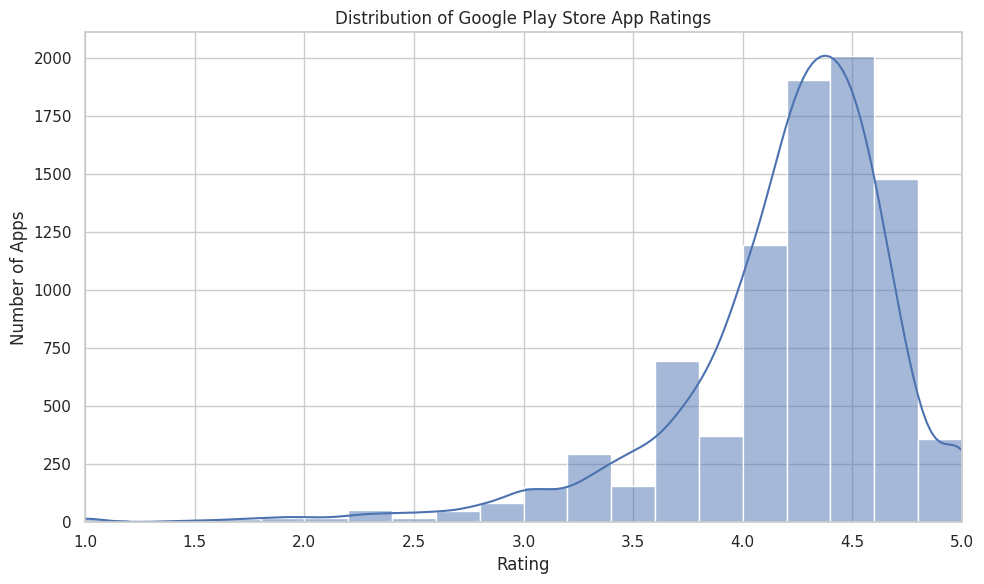

In [41]:
# Rating Distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    apps_analysis["Rating"].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribution of Google Play Store App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.xlim(1, 5)

plt.tight_layout()
plt.show()

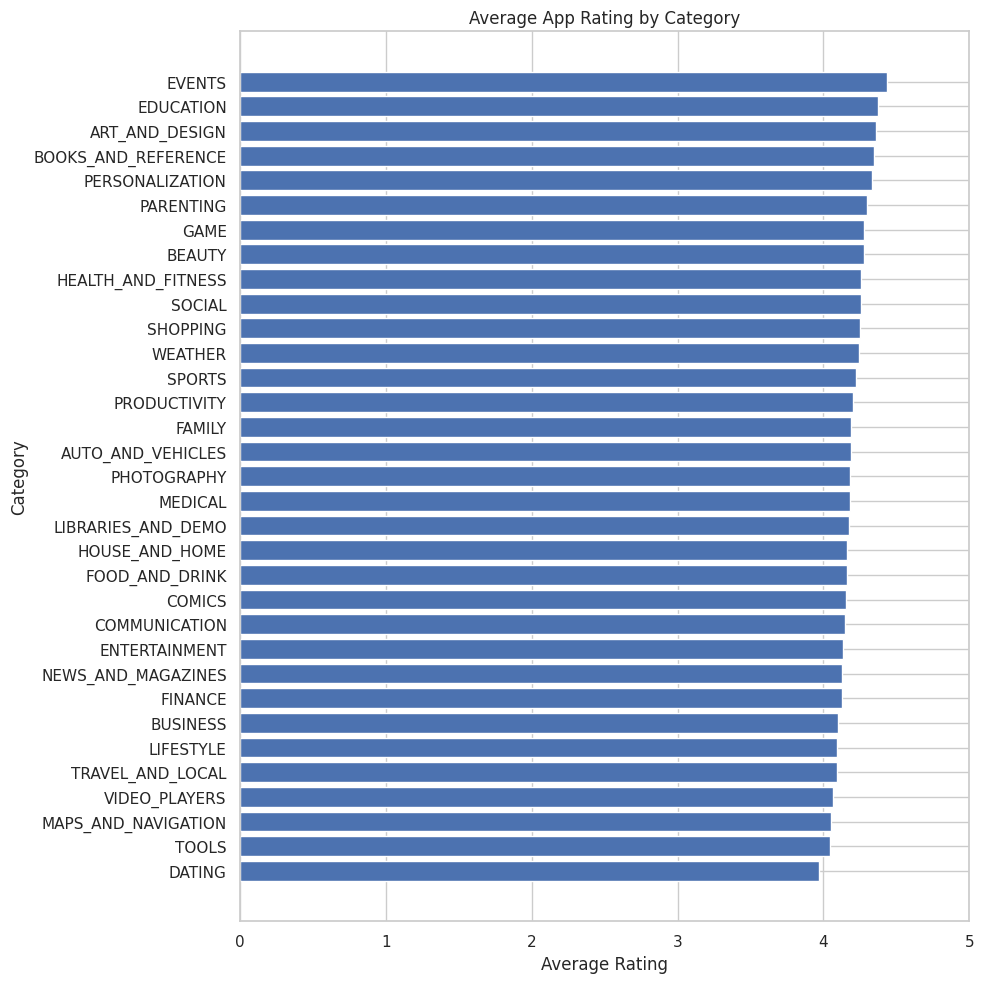

In [42]:
# Average Rating by Category

avg_rating_by_category = (
    apps_analysis
    .groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 10))

plt.barh(
    avg_rating_by_category.index,
    avg_rating_by_category.values
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [43]:
#Hihest and Lowest Averages

print("Top 10 categories by average rating:")
print(avg_rating_by_category.sort_values(ascending=False).head(10))

print("\nBottom 10 categories by average rating:")
print(avg_rating_by_category.head(10))

Top 10 categories by average rating:
Category
EVENTS                 4.435556
EDUCATION              4.375969
ART_AND_DESIGN         4.358065
BOOKS_AND_REFERENCE    4.347458
PERSONALIZATION        4.333871
PARENTING              4.300000
GAME                   4.281285
BEAUTY                 4.278571
HEALTH_AND_FITNESS     4.261450
SOCIAL                 4.254918
Name: Rating, dtype: float64

Bottom 10 categories by average rating:
Category
DATING                 3.971698
TOOLS                  4.047411
MAPS_AND_NAVIGATION    4.051613
VIDEO_PLAYERS          4.063750
TRAVEL_AND_LOCAL       4.094146
LIFESTYLE              4.096066
BUSINESS               4.102593
FINANCE                4.127445
NEWS_AND_MAGAZINES     4.128505
ENTERTAINMENT          4.136036
Name: Rating, dtype: float64


In [44]:
# Preparing data for Size vs. Installs analysis

size_installs = apps_analysis[
    ["App", "Size", "Installs"]
].dropna().copy()

print("Records available for Size vs. Installs analysis:",
      len(size_installs))

print("\nMissing values:")
print(size_installs[["Size", "Installs"]].isnull().sum())

Records available for Size vs. Installs analysis: 8831

Missing values:
Size        0
Installs    0
dtype: int64


In [45]:
#Basic Statistics
print("Size statistics:")
print(size_installs["Size"].describe())

print("\nInstalls statistics:")
print(size_installs["Installs"].describe())

Size statistics:
count    8831.000000
mean       21.287413
std        22.540591
min         0.008301
25%         4.700000
50%        13.000000
75%        29.000000
max       100.000000
Name: Size, dtype: float64

Installs statistics:
count    8.831000e+03
mean     6.577887e+06
std      4.255139e+07
min      0.000000e+00
25%      1.000000e+03
50%      5.000000e+04
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64


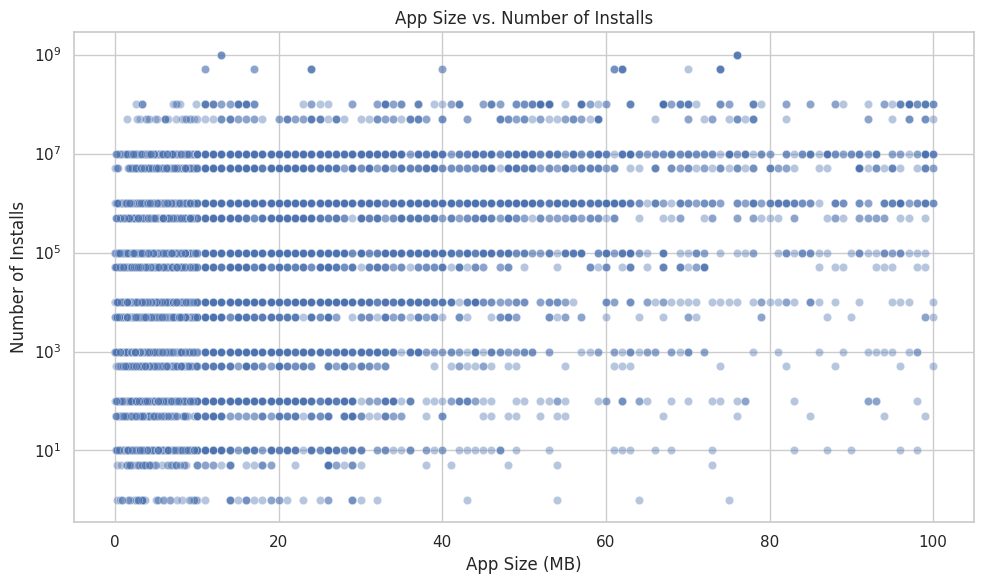

In [46]:
# App Size vs. Number of Installs

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_installs,
    x="Size",
    y="Installs",
    alpha=0.4
)

plt.title("App Size vs. Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.yscale("log")

plt.tight_layout()
plt.show()

In [47]:
# Pearson correlation between app size and installs

correlation = size_installs["Size"].corr(
    size_installs["Installs"]
)

print("Pearson correlation between Size and Installs:",
      round(correlation, 4))

Pearson correlation between Size and Installs: 0.1689


In [48]:
# Correlation after log-transforming install counts

size_installs["Log_Installs"] = np.log10(
    size_installs["Installs"].replace(0, np.nan)
)

log_correlation = size_installs["Size"].corr(
    size_installs["Log_Installs"]
)

print(
    "Pearson correlation between Size and log10(Installs):",
    round(log_correlation, 4)
)

Pearson correlation between Size and log10(Installs): 0.3336


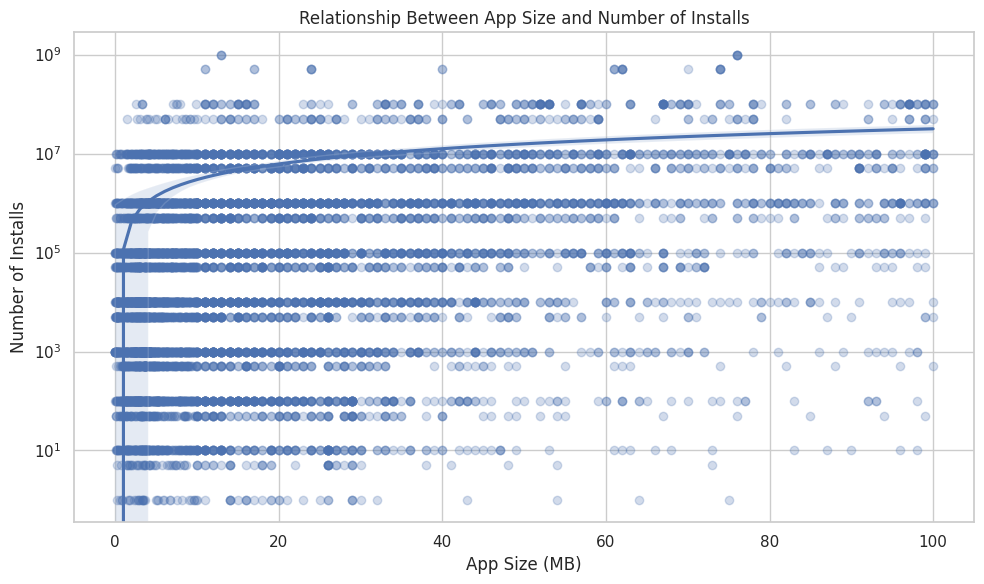

In [49]:
# Size vs. Installs with Trendline

plt.figure(figsize=(10, 6))

sns.regplot(
    data=size_installs,
    x="Size",
    y="Installs",
    scatter_kws={"alpha": 0.25},
    line_kws={}
)

plt.title("Relationship Between App Size and Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.yscale("log")

plt.tight_layout()
plt.show()

# **Size & Installs Analysis**

In [50]:
# Preparing data for Size vs. Installs analysis

size_installs = apps_analysis[
    ["App", "Size", "Installs"]
].dropna().copy()

print("Records available for Size vs. Installs analysis:",
      len(size_installs))

print("\nMissing values:")
print(size_installs[["Size", "Installs"]].isnull().sum())

Records available for Size vs. Installs analysis: 8831

Missing values:
Size        0
Installs    0
dtype: int64


In [51]:
# Basic statistics for Size and Installs

print("Size statistics:")
print(size_installs["Size"].describe())

print("\nInstalls statistics:")
print(size_installs["Installs"].describe())

Size statistics:
count    8831.000000
mean       21.287413
std        22.540591
min         0.008301
25%         4.700000
50%        13.000000
75%        29.000000
max       100.000000
Name: Size, dtype: float64

Installs statistics:
count    8.831000e+03
mean     6.577887e+06
std      4.255139e+07
min      0.000000e+00
25%      1.000000e+03
50%      5.000000e+04
75%      1.000000e+06
max      1.000000e+09
Name: Installs, dtype: float64


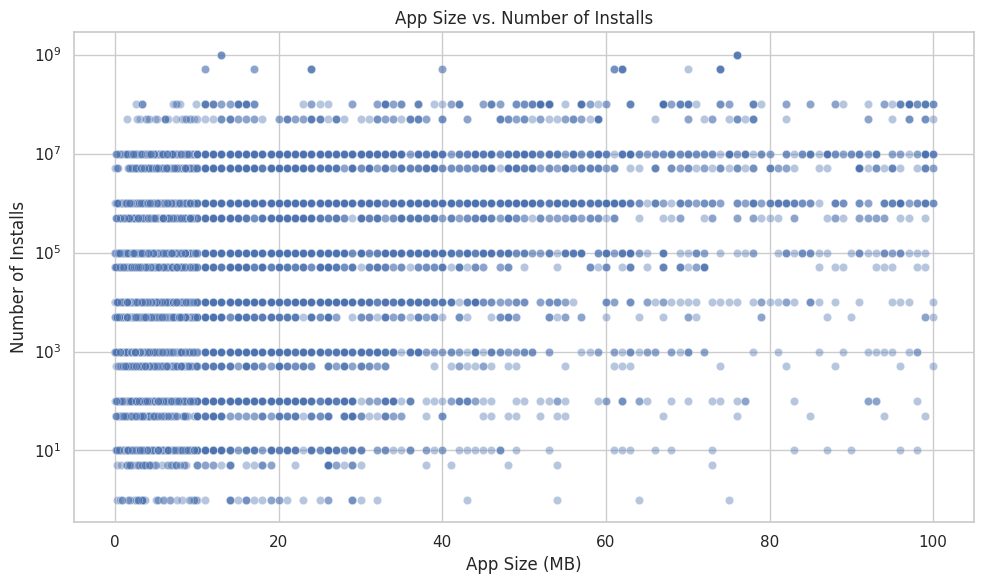

In [52]:
# App Size vs. Number of Installs

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_installs,
    x="Size",
    y="Installs",
    alpha=0.4
)

plt.title("App Size vs. Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.yscale("log")

plt.tight_layout()
plt.show()

In [53]:
# Pearson correlation between app size and installs

correlation = size_installs["Size"].corr(
    size_installs["Installs"]
)

print(
    "Pearson correlation between Size and Installs:",
    round(correlation, 4)
)

Pearson correlation between Size and Installs: 0.1689


In [54]:
# Correlation after log-transforming install counts

size_installs["Log_Installs"] = np.log10(
    size_installs["Installs"].replace(0, np.nan)
)

log_correlation = size_installs["Size"].corr(
    size_installs["Log_Installs"]
)

print(
    "Pearson correlation between Size and log10(Installs):",
    round(log_correlation, 4)
)

Pearson correlation between Size and log10(Installs): 0.3336


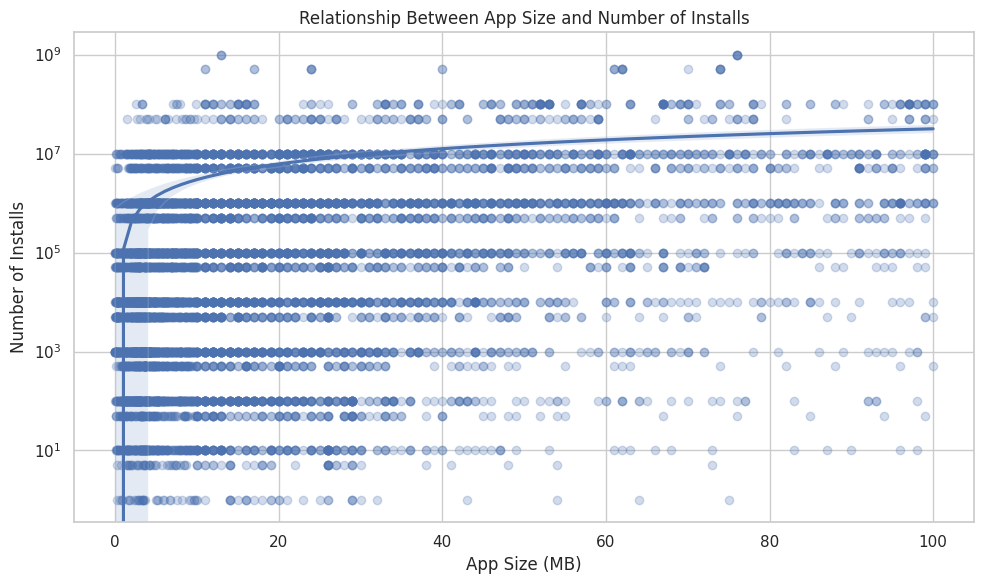

In [55]:
# Size vs. Installs with Trendline

plt.figure(figsize=(10, 6))

sns.regplot(
    data=size_installs,
    x="Size",
    y="Installs",
    scatter_kws={"alpha": 0.25},
    line_kws={}
)

plt.title("Relationship Between App Size and Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.yscale("log")

plt.tight_layout()
plt.show()

### Size and Installs Analysis

To investigate whether larger apps tend to receive more installs, apps with both recorded size and install values were selected, resulting in **8,831 usable records**.

App size had a median of **13 MB** and a maximum of **100 MB**, while install counts ranged from 0 to **1 billion**. Because install counts were highly skewed, a logarithmic scale was used in the scatter plot to make the relationship easier to observe.

The Pearson correlation between raw app size and installs was **0.1689**, indicating a weak positive relationship. After applying a log transformation to install counts, the correlation increased to **0.3336**, suggesting a moderate positive association.

Overall, the results indicate that larger apps tend to be associated with higher install counts to some extent, but app size alone does not strongly explain an app's number of installs. Other factors such as category, app quality, functionality, user experience, and popularity are likely to influence adoption.

# **Pricing Analysis**

In [56]:
# Pricing Analysis - Free vs Paid Apps

type_counts = apps_analysis["Type"].value_counts(dropna=False)

print("App Type Distribution:")
print(type_counts)

App Type Distribution:
Type
Free    9591
Paid     765
NaN        1
Name: count, dtype: int64


In [57]:
# Percentage distribution of Free vs Paid apps

type_percentages = (
    apps_analysis["Type"]
    .value_counts(normalize=True, dropna=True)
    .mul(100)
)

print("Percentage of Free vs Paid apps:")
print(type_percentages.round(2))

Percentage of Free vs Paid apps:
Type
Free    92.61
Paid     7.39
Name: proportion, dtype: float64


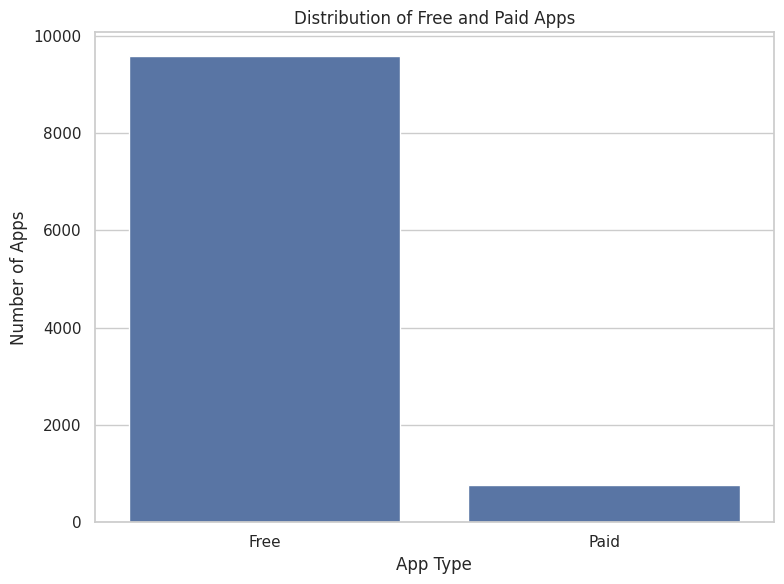

In [58]:
# Free vs Paid App Distribution

plt.figure(figsize=(8, 6))

sns.countplot(
    data=apps_analysis,
    x="Type"
)

plt.title("Distribution of Free and Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

In [59]:
# Filtering Paid Apps

paid_apps = apps_analysis[
    apps_analysis["Price"] > 0
].copy()

print("Number of paid apps:", len(paid_apps))

print("\nPaid app price statistics:")
print(paid_apps["Price"].describe())

Number of paid apps: 765

Paid app price statistics:
count    765.000000
mean      13.955556
std       58.406966
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


In [60]:
print("\nMost common paid app prices:")
print(paid_apps["Price"].value_counts().head(15))


Most common paid app prices:
Price
0.99      146
2.99      125
1.99       73
4.99       70
3.99       60
1.49       46
5.99       27
2.49       25
9.99       19
6.99       12
399.99     12
4.49        9
14.99       9
7.99        7
3.49        7
Name: count, dtype: int64


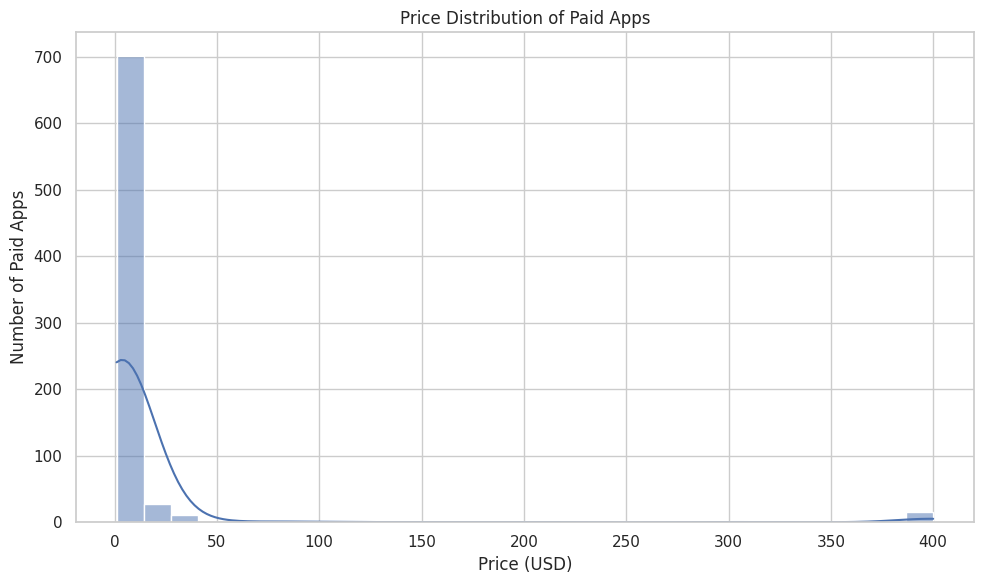

In [61]:
# Price Distribution of Paid Apps

plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Paid Apps")

plt.tight_layout()
plt.show()

In [62]:
# Estimating Minimum Gross Revenue for Paid Apps

paid_apps["Estimated_Min_Revenue"] = (
    paid_apps["Price"] * paid_apps["Installs"]
)

print("Sample revenue estimates:")
display(
    paid_apps[
        ["App", "Category", "Price", "Installs", "Estimated_Min_Revenue"]
    ].head(10)
)

Sample revenue estimates:


,App,Category,Price,Installs,Estimated_Min_Revenue
234,TurboScan: scan documents and receipts in PDF,BUSINESS,4.99,100000.0,499000.0
235,Tiny Scanner Pro: PDF Doc Scan,BUSINESS,4.99,100000.0,499000.0
427,Puffin Browser Pro,COMMUNICATION,3.99,100000.0,399000.0
476,"Moco+ - Chat, Meet People",DATING,3.99,10000.0,39900.0
477,Calculator,DATING,6.99,1000.0,6990.0
478,Truth or Dare Pro,DATING,1.49,50.0,74.5
479,"Private Dating, Hide App- Blue for PrivacyHider",DATING,2.99,100.0,299.0
480,Ad Blocker for SayHi,DATING,3.99,100.0,399.0
481,AMBW Dating App: Asian Men Black Women Interra...,DATING,7.99,100.0,799.0
571,"Moco+ - Chat, Meet People",DATING,3.99,10000.0,39900.0


In [63]:
# Estimated Minimum Revenue by Category

revenue_by_category = (
    paid_apps
    .groupby("Category")["Estimated_Min_Revenue"]
    .sum()
    .sort_values(ascending=False)
)

print("Top 10 categories by estimated minimum gross revenue:")
print(revenue_by_category.head(10))

Top 10 categories by estimated minimum gross revenue:
Category
FAMILY             1.857803e+08
LIFESTYLE          5.758394e+07
GAME               4.098764e+07
FINANCE            2.572668e+07
PHOTOGRAPHY        8.942768e+06
MEDICAL            8.456536e+06
PERSONALIZATION    7.786948e+06
TOOLS              5.464821e+06
SPORTS             4.706212e+06
PRODUCTIVITY       4.313375e+06
Name: Estimated_Min_Revenue, dtype: float64


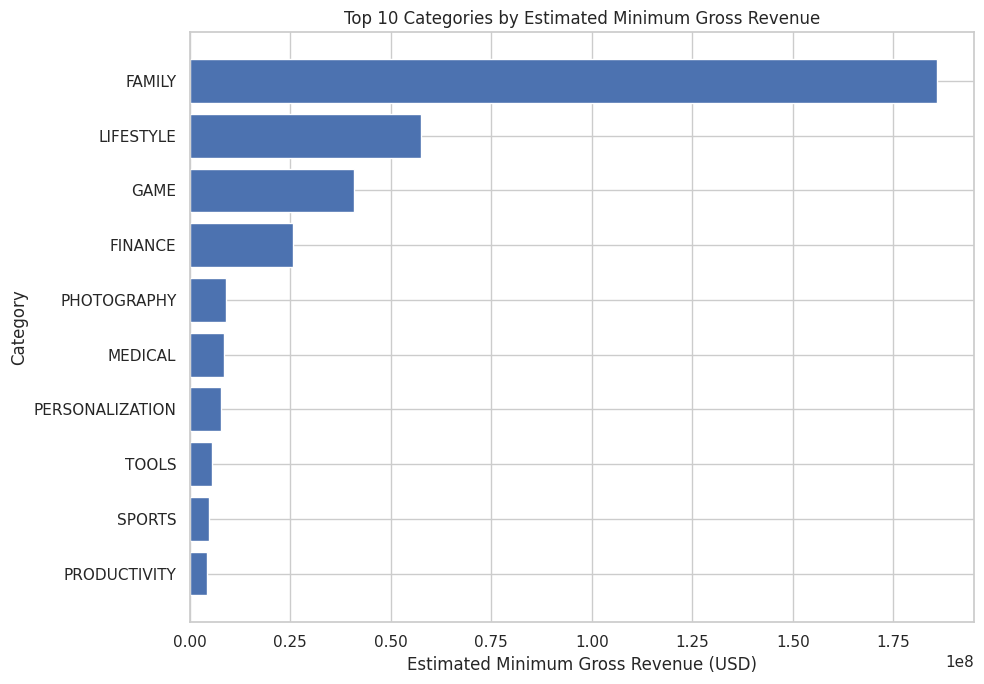

In [64]:
# Top 10 Categories by Estimated Minimum Gross Revenue

top_revenue_categories = revenue_by_category.head(10).sort_values()

plt.figure(figsize=(10, 7))

plt.barh(
    top_revenue_categories.index,
    top_revenue_categories.values
)

plt.title("Top 10 Categories by Estimated Minimum Gross Revenue")
plt.xlabel("Estimated Minimum Gross Revenue (USD)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

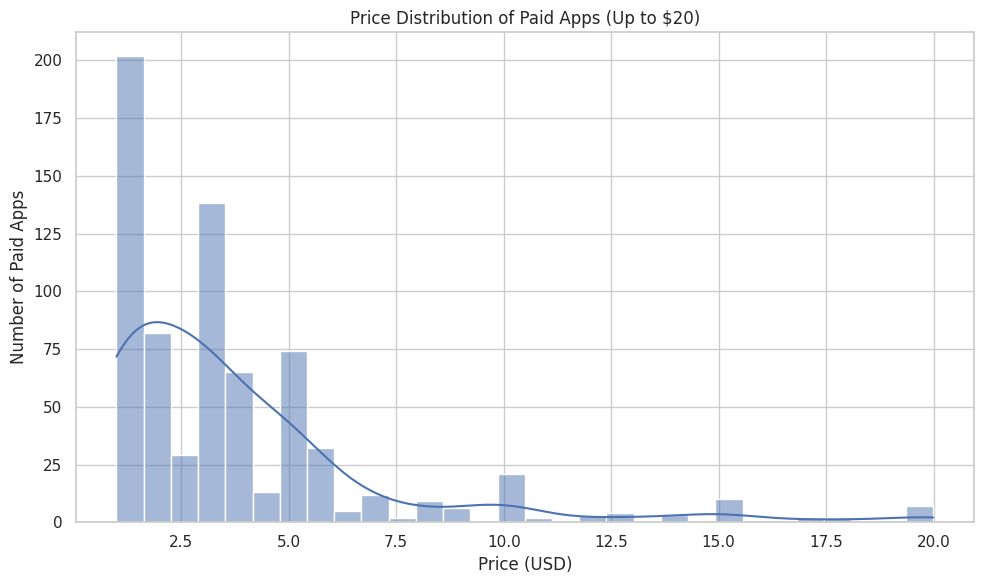

In [65]:
# Focused Price Distribution of Paid Apps

plt.figure(figsize=(10, 6))

sns.histplot(
    paid_apps[paid_apps["Price"] <= 20]["Price"],
    bins=30,
    kde=True
)

plt.title("Price Distribution of Paid Apps (Up to $20)")
plt.xlabel("Price (USD)")
plt.ylabel("Number of Paid Apps")

plt.tight_layout()
plt.show()

### Pricing Analysis

The Apps dataset was examined to compare free and paid apps, understand pricing patterns among paid apps, and estimate potential gross revenue by category.

The dataset contains **9,591 free apps (92.61%)** and **765 paid apps (7.39%)**, showing that free apps make up the large majority of the available apps.

Among paid apps, the median price was **$2.99**, while the mean price was **$13.96**. The difference is largely influenced by a small number of high-priced apps, including apps priced at **$399.99**. The most common paid-app price was **$0.99**, followed by **$2.99** and **$1.99**, indicating that most paid apps are positioned at relatively low price points.

For the revenue analysis, a conservative estimate of minimum gross revenue was calculated as:

`Price × minimum reported installs`

Because the original install values represent lower-bound ranges such as `10,000+`, the resulting figures should not be interpreted as actual revenue. They also do not account for platform fees, taxes, refunds, or whether every reported install represents a paid purchase.

Using this approach, the FAMILY category had the highest estimated minimum gross revenue at approximately **$185.8 million**, followed by LIFESTYLE at **$57.6 million** and GAME at **$41.0 million**.

# **Sentiment analysis on user reviews**

In [66]:
!pip -q install vaderSentiment

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

print("VADER sentiment analyzer is ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00
VADER sentiment analyzer is ready.


In [67]:
sentiment_reviews = reviews_analysis[
    ["App", "Translated_Review"]
].dropna(subset=["Translated_Review"]).copy()

print("Reviews available for sentiment analysis:", len(sentiment_reviews))
print("Missing review text:", sentiment_reviews["Translated_Review"].isna().sum())

Reviews available for sentiment analysis: 29692
Missing review text: 0


In [68]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

sentiment_reviews["Sentiment_VADER"] = (
    sentiment_reviews["Translated_Review"].apply(get_sentiment)
)

print("Sentiment analysis completed.")
sentiment_reviews.head()

Sentiment analysis completed.


,App,Translated_Review,Sentiment_VADER
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive
3,10 Best Foods for You,Works great especially going grocery store,Positive
4,10 Best Foods for You,Best idea us,Positive
5,10 Best Foods for You,Best way,Positive


In [69]:
sentiment_counts = sentiment_reviews["Sentiment_VADER"].value_counts()

print(sentiment_counts)
print("\nPercentage:")
print((sentiment_counts / len(sentiment_reviews) * 100).round(2))

Sentiment_VADER
Positive    20197
Negative     5866
Neutral      3629
Name: count, dtype: int64

Percentage:
Sentiment_VADER
Positive    68.02
Negative    19.76
Neutral     12.22
Name: count, dtype: float64


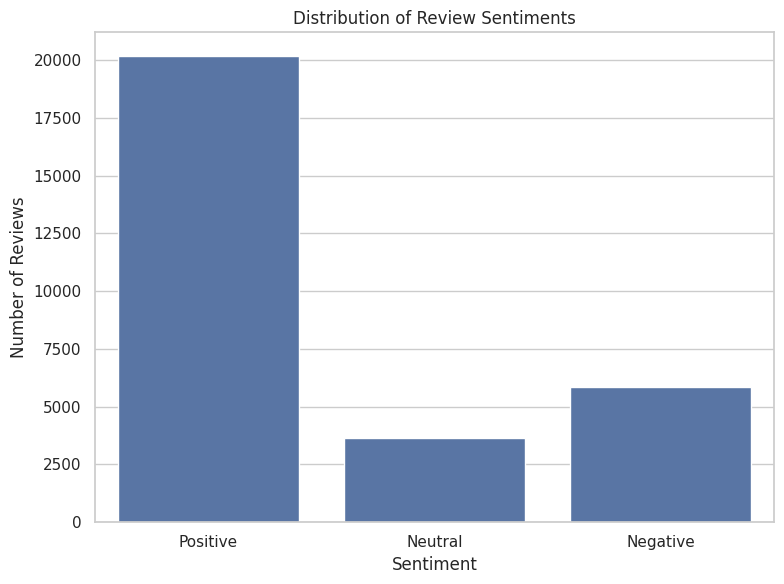

In [70]:
# Creating Charts

plt.figure(figsize=(8, 6))

sns.countplot(
    data=sentiment_reviews,
    x="Sentiment_VADER",
    order=["Positive", "Neutral", "Negative"]
)

plt.title("Distribution of Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

In [71]:
app_category_map = (
    apps_analysis[["App", "Category"]]
    .drop_duplicates()
)

print("Unique App-Category pairs:", len(app_category_map))
print("Apps with multiple categories:",
      app_category_map["App"].duplicated().sum())

Unique App-Category pairs: 9744
Apps with multiple categories: 85


In [72]:
#Checking 85 Conflicting Apps

category_conflicts = (
    app_category_map
    .groupby("App")["Category"]
    .nunique()
    .sort_values(ascending=False)
)

conflicting_apps = category_conflicts[category_conflicts > 1]

print("Apps with multiple categories:", len(conflicting_apps))
print("\nExamples:")
print(conflicting_apps.head(20))

Apps with multiple categories: 85

Examples:
App
The CW                                              2
Choices: Stories You Play                           2
Idle Heroes                                         2
Toca Life: City                                     2
Final Fantasy XV: A New Empire                      2
Food Network                                        2
UNICORN - Color By Number & Pixel Art Coloring      2
Candy Bomb                                          2
Video Editor                                        2
Candy Crush Saga                                    2
Calculator                                          2
Dungeon Hunter Champions: Epic Online Action RPG    2
Game for KIDS: KIDS match'em                        2
ROBLOX                                              2
Showtime Anytime                                    2
English Grammar Test                                2
Flow Free                                           2
CppDroid - C/C++ IDE             

In [73]:
conflict_details = (
    app_category_map[
        app_category_map["App"].isin(conflicting_apps.index)
    ]
    .sort_values("App")
)

conflict_details.head(30)

,App,Category
3953,8 Ball Pool,SPORTS
1675,8 Ball Pool,GAME
920,A&E - Watch Full Episodes of TV Shows,ENTERTAINMENT
4991,A&E - Watch Full Episodes of TV Shows,FAMILY
1843,Angry Birds 2,GAME
4864,Angry Birds 2,FAMILY
717,Babbel – Learn Languages,EDUCATION
8297,Babbel – Learn Languages,FAMILY
2045,Barbie™ Fashion Closet,FAMILY
1687,Barbie™ Fashion Closet,GAME


In [75]:
#Removing app that are appearing in more than one category


unambiguous_app_category_map = app_category_map[
    ~app_category_map["App"].isin(conflicting_apps.index)
].copy()

print("Unambiguous App-Category pairs:",
      len(unambiguous_app_category_map))

print("Ambiguous apps excluded:",
      len(conflicting_apps))

Unambiguous App-Category pairs: 9574
Ambiguous apps excluded: 85


In [76]:
# Now Merging them
sentiment_by_category = sentiment_reviews.merge(
    unambiguous_app_category_map,
    on="App",
    how="left"
)

print("Sentiment reviews:", len(sentiment_reviews))
print("Rows after merge:", len(sentiment_by_category))
print("Missing categories:",
      sentiment_by_category["Category"].isna().sum())

Sentiment reviews: 29692
Rows after merge: 29692
Missing categories: 2831


In [78]:
#Removing unmatched reviews

sentiment_by_category = sentiment_by_category.dropna(
    subset=["Category"]
).copy()

print("Final reviews for category sentiment:",
      len(sentiment_by_category))

Final reviews for category sentiment: 26861


In [79]:
category_sentiment = pd.crosstab(
    sentiment_by_category["Category"],
    sentiment_by_category["Sentiment_VADER"],
    normalize="index"
) * 100

category_sentiment = category_sentiment[
    ["Positive", "Neutral", "Negative"]
].sort_values("Positive", ascending=False)

category_sentiment.round(2)

Sentiment_VADER,Positive,Neutral,Negative
Category,,,
COMICS,86.67,11.11,2.22
AUTO_AND_VEHICLES,82.33,12.72,4.95
EVENTS,80.13,7.69,12.18
HEALTH_AND_FITNESS,78.47,7.90,13.63
EDUCATION,77.48,11.98,10.54
ART_AND_DESIGN,76.05,11.68,12.28
FOOD_AND_DRINK,73.76,10.98,15.27
PARENTING,73.44,16.02,10.55
FAMILY,72.86,10.16,16.98


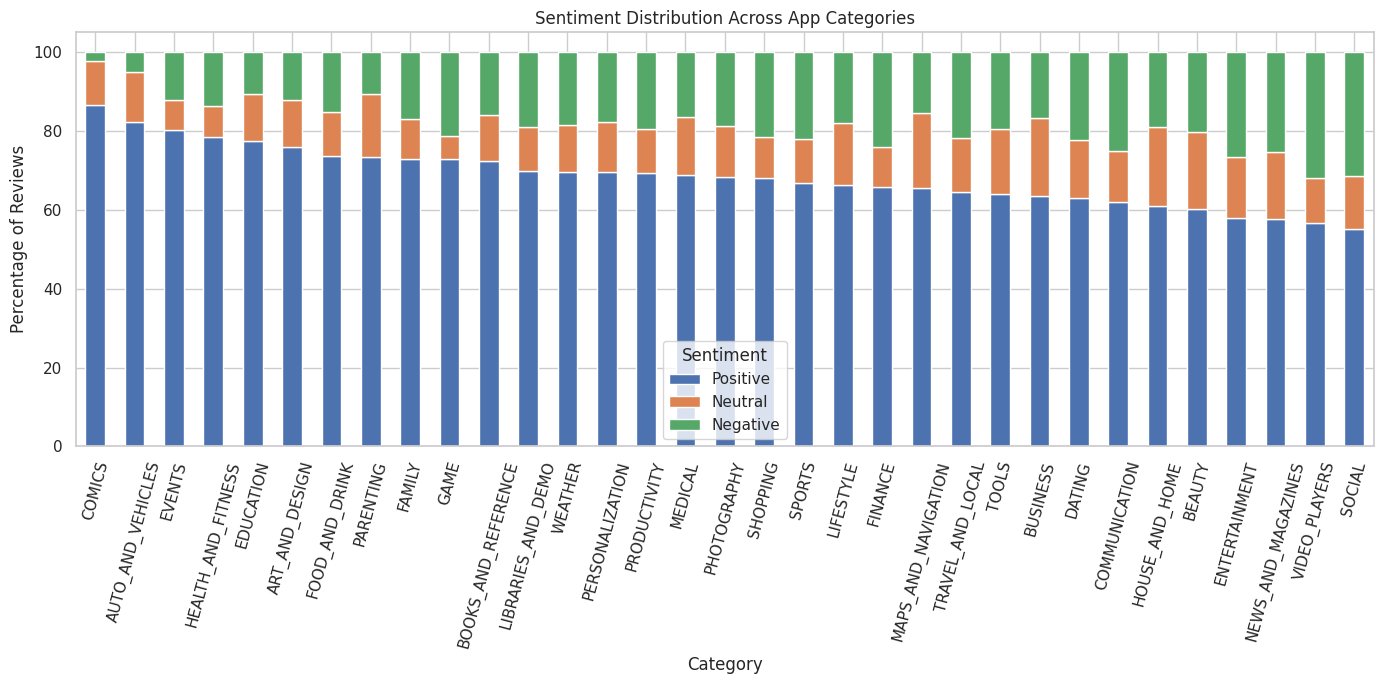

In [80]:
#Now Making the Chart

category_sentiment.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.title("Sentiment Distribution Across App Categories")
plt.xlabel("Category")
plt.ylabel("Percentage of Reviews")
plt.legend(title="Sentiment")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

# **Create one interactive Plotly visualization**

In [81]:
!pip -q install plotly

import plotly.express as px

In [82]:
plotly_data = category_sentiment.reset_index().melt(
    id_vars="Category",
    var_name="Sentiment",
    value_name="Percentage"
)

fig = px.bar(
    plotly_data,
    x="Category",
    y="Percentage",
    color="Sentiment",
    barmode="stack",
    title="Interactive Sentiment Distribution by App Category",
    labels={
        "Percentage": "Percentage of Reviews",
        "Category": "App Category"
    }
)

fig.update_layout(
    xaxis_tickangle=-60,
    height=700
)

fig.show()

In [83]:
# Generating few numbers for our final conclusions

top_positive = category_sentiment["Positive"].idxmax()
top_negative = category_sentiment["Negative"].idxmax()

print("Highest positive sentiment:", top_positive,
      round(category_sentiment.loc[top_positive, "Positive"], 2), "%")

print("Highest negative sentiment:", top_negative,
      round(category_sentiment.loc[top_negative, "Negative"], 2), "%")

print("\nOverall positive sentiment:",
      round(sentiment_counts["Positive"] / len(sentiment_reviews) * 100, 2), "%")

print("Overall negative sentiment:",
      round(sentiment_counts["Negative"] / len(sentiment_reviews) * 100, 2), "%")

Highest positive sentiment: COMICS 86.67 %
Highest negative sentiment: VIDEO_PLAYERS 31.9 %

Overall positive sentiment: 68.02 %
Overall negative sentiment: 19.76 %


In [84]:
#number of reviews behind each category percentage

category_review_counts = (
    sentiment_by_category["Category"]
    .value_counts()
    .sort_values(ascending=False)
)

print(category_review_counts.head(10))

Category
GAME                  3399
FAMILY                1802
HEALTH_AND_FITNESS    1621
TOOLS                 1398
FINANCE               1336
TRAVEL_AND_LOCAL      1331
SPORTS                1216
MEDICAL               1156
PRODUCTIVITY          1135
DATING                1087
Name: count, dtype: int64


## Conclusion: Recommendations for App Developers

The analysis of the Google Play Store dataset and user reviews provides several useful insights for developers planning to launch a new Android app:

1. **Choose the market carefully and differentiate in saturated categories.**
   The **GAME** category contains **3,399 apps**, making it the most saturated category in the dataset, followed by FAMILY (1,802) and HEALTH_AND_FITNESS (1,621). Entering a highly competitive category therefore requires a clear value proposition or differentiation from existing apps.

2. **Focus on user experience rather than app size alone.**
   The relationship between app size and installs was relatively weak, with a **0.3336 correlation after log-transforming installs**. This suggests that simply making an app smaller or larger does not explain its adoption. Developers should instead prioritize useful functionality, performance, and the needs of their target users. This is also supported by the sentiment analysis, where user sentiment varied considerably across categories.

3. **Build a monetization strategy around perceived value.**
   Only **7.39% of apps were paid**, and the **median price of paid apps was $2.99**. This indicates that paid apps represent a relatively small portion of the market. Developers considering a paid model should therefore provide a strong reason for users to pay, while the estimated revenue results show that categories such as **FAMILY, LIFESTYLE, and GAME** can still offer meaningful monetization potential.

Overall, the findings suggest that successful app development is not simply about entering a popular category or maximizing installs. Developers should identify an appropriate market, understand the expectations and sentiment of its users, differentiate their product, and select a monetization strategy that matches the value delivered.
